<a href="https://colab.research.google.com/github/dian-l564/Despliegue/blob/main/categoria_vehiculo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
import pandas as pd

subido = files.upload()          # elegir el archivo
df = pd.read_csv("categoria_precio.csv")

print(df.shape)
print(df["categoria_precio"].value_counts())
df.head()

Saving categoria_precio.csv to categoria_precio.csv
(26306, 10)
categoria_precio
gama_media    8781
gama_baja     8765
gama_alta     8760
Name: count, dtype: int64


,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,brand,categoria_precio
0,i3,2014,Automatic,34539,Hybrid,0,470.8,0.6,BMW,gama_baja
1,i3,2014,Automatic,37161,Hybrid,0,470.8,0.6,BMW,gama_baja
2,i3,2014,Automatic,42479,Hybrid,0,470.8,0.6,BMW,gama_media
3,i3,2015,Automatic,9886,Hybrid,0,470.8,0.6,BMW,gama_media
4,i3,2015,Automatic,33931,Hybrid,0,470.8,0.6,BMW,gama_media


In [3]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('categoria_precio.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [5]:
#cargar datos y quitar duplicados
df = pd.read_csv("categoria_precio.csv")
print("Filas duplicadas:", df.duplicated().sum())

df = df.drop_duplicates()
print("Dimensiones finales:", df.shape)
df["categoria_precio"].value_counts()

Filas duplicadas: 791
Dimensiones finales: (25515, 10)


,count
categoria_precio,
gama_baja,8643
gama_media,8612
gama_alta,8260


In [6]:
X = df.drop(columns="categoria_precio")   # las 9 características del vehículo
y = df["categoria_precio"]                # lo que queremos predecir

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Entrenamiento:", X_train.shape, "| Prueba:", X_test.shape)

Entrenamiento: (20412, 9) | Prueba: (5103, 9)


In [8]:
#preprocesamiento
categoricas = ["model", "transmission", "fuelType", "brand"]
numericas   = ["year", "mileage", "tax", "mpg", "engineSize"]

preprocesador = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categoricas),
    ("num", StandardScaler(), numericas),
])

In [9]:
#Entrenar y comparar los 3 modelos
modelos = {
    "Regresión logística": LogisticRegression(max_iter=2000),
    "Árbol de decisión":   DecisionTreeClassifier(max_depth=12, min_samples_leaf=5, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=300, min_samples_leaf=2, n_jobs=-1, random_state=42),
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
resultados = []
pipelines = {}

for nombre, modelo in modelos.items():
    pipe = Pipeline([("prep", preprocesador), ("clf", modelo)])

    # Validación cruzada de 10 pliegues (solo con datos de entrenamiento)
    puntajes = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)

    # Entrenar con todo el train y evaluar en el test
    pipe.fit(X_train, y_train)
    acc_test = accuracy_score(y_test, pipe.predict(X_test))

    pipelines[nombre] = pipe
    resultados.append([nombre, f"{puntajes.mean():.1%}", f"{acc_test:.1%}"])

pd.DataFrame(resultados, columns=["Modelo", "Validación cruzada (10 pliegues)", "Test (20%)"])

,Modelo,Validación cruzada (10 pliegues),Test (20%)
0,Regresión logística,88.5%,88.3%
1,Árbol de decisión,88.1%,87.4%
2,Random Forest,90.6%,90.7%


              precision    recall  f1-score   support

   gama_baja      0.927     0.922     0.925      1729
  gama_media      0.855     0.876     0.865      1722
   gama_alta      0.943     0.924     0.933      1652

    accuracy                          0.907      5103
   macro avg      0.908     0.908     0.908      5103
weighted avg      0.908     0.907     0.908      5103



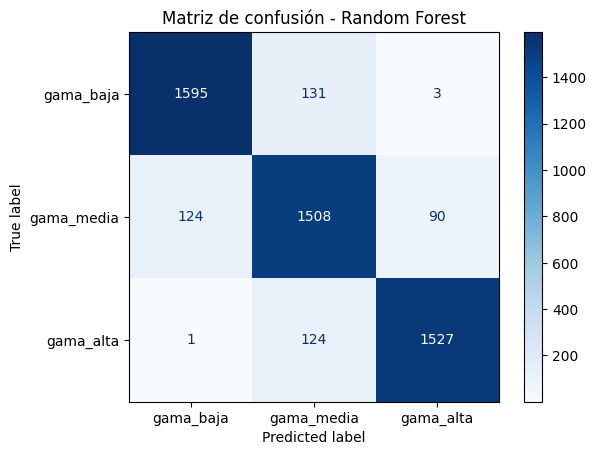

In [10]:
# Evaluación detallada del modelo
mejor = pipelines["Random Forest"]
pred = mejor.predict(X_test)
orden = ["gama_baja", "gama_media", "gama_alta"]

print(classification_report(y_test, pred, labels=orden, digits=3))

cm = confusion_matrix(y_test, pred, labels=orden)
ConfusionMatrixDisplay(cm, display_labels=orden).plot(cmap="Blues")
plt.title("Matriz de confusión - Random Forest")
plt.show()

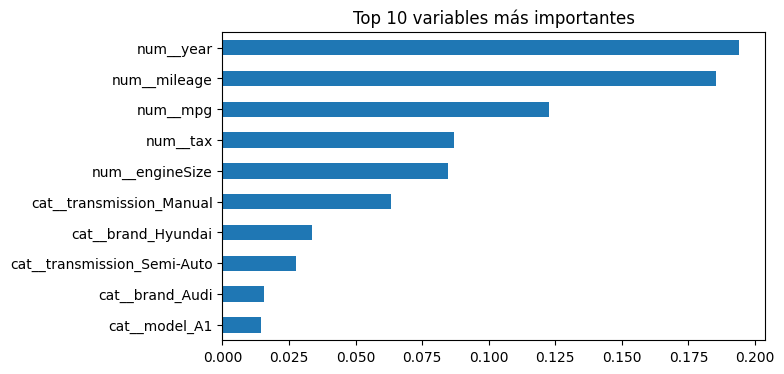

In [11]:
#variables influyentes
nombres = mejor.named_steps["prep"].get_feature_names_out()
importancia = pd.Series(mejor.named_steps["clf"].feature_importances_, index=nombres)

top = importancia.sort_values(ascending=False).head(10)
top.sort_values().plot(kind="barh", figsize=(7, 4), title="Top 10 variables más importantes")
plt.show()

In [13]:
# Predcir vehículo nuevo
nuevo = pd.DataFrame([{
    "model": "3 Series", "year": 2018, "transmission": "Automatic",
    "mileage": 30000, "fuelType": "Diesel", "tax": 145,
    "mpg": 55.0, "engineSize": 2.0, "brand": "BMW"
}])

print("Categoría predicha:", mejor.predict(nuevo)[0])
print(dict(zip(mejor.classes_, mejor.predict_proba(nuevo)[0].round(3))))

Categoría predicha: gama_media
{'gama_alta': np.float64(0.255), 'gama_baja': np.float64(0.06), 'gama_media': np.float64(0.685)}
